# 📊 Часть 1: Загрузка и первичный анализ данных

В этом разделе происходит инициализация окружения и загрузка основного датасета **абсолютных валютных курсов**. Эти данные уникальны тем, что представляют стоимость валют не относительно одного «якоря» (как USD), а как абсолютное значение внутри диверсифицированной корзины.

**Основные задачи этапа:**
* Загрузка набора данных `abscur.csv` из родительского исследования (abscur2).
* Преобразование временных рядов для корректного исторического анализа.
* Проверка структуры тикеров валют (AED, ARS, RUB и др.).


In [1]:
import pandas as pd

# Путь к файлу из подключенного источника
file_path = '/kaggle/input/notebooks/eavprog/abscur2/abscur.csv'

# Загрузка данных
# Указываем parse_dates=['Date'], чтобы pandas сразу распознал колонку с датами
df = pd.read_csv(file_path, parse_dates=['Date'])

# Вывод первых 5 строк для проверки
df.head()

,Date,AED,ARS,AUD,BRL,CAD,CHF,CLP,CNY,COP,...,SAR,SEK,SGD,THB,TRY,TWD,UAH,USD,VND,ZAR
0,2006-07-26,3.899127,1.683297,10.833273,5.596520,12.290462,15.542383,0.024429,1.826164,0.006823,...,3.817437,1.652881,11.461439,0.436897,6.317656,0.442185,0.989703,14.321495,0.000673,1.282229
1,2006-07-27,3.899043,1.683261,10.833338,5.596399,12.290536,15.542476,0.024428,1.827093,0.006823,...,3.817354,1.652891,11.461507,0.436888,6.317519,0.442176,0.989681,14.321184,0.000673,1.282238
2,2006-07-28,3.899011,1.683247,10.833362,5.596353,12.290563,15.542511,0.024428,1.827441,0.006823,...,3.817323,1.652895,11.461533,0.436884,6.317468,0.442172,0.989673,14.321067,0.000673,1.282242
3,2006-07-31,3.899000,1.683243,10.833370,5.596338,12.290573,15.542522,0.024428,1.827557,0.006823,...,3.817312,1.652897,11.461542,0.436883,6.317450,0.442171,0.989671,14.321028,0.000673,1.282243
4,2006-08-01,3.899032,1.683256,10.833346,5.596383,12.290545,15.542487,0.024428,1.827209,0.006823,...,3.817343,1.652893,11.461516,0.436887,6.317502,0.442174,0.989679,14.321145,0.000673,1.282239


# 📉 Часть 2: Расчет и визуализация максимальной просадки (MDD)
В этой части мы определим функцию для расчета **Maximum Drawdown** — ключевого показателя риска, который измеряет наибольшее падение стоимости актива от локального максимума до последующего минимума. 

Мы визуализируем подводные камни (underwater chart) на примере одной из валют, чтобы наглядно увидеть периоды восстановления.

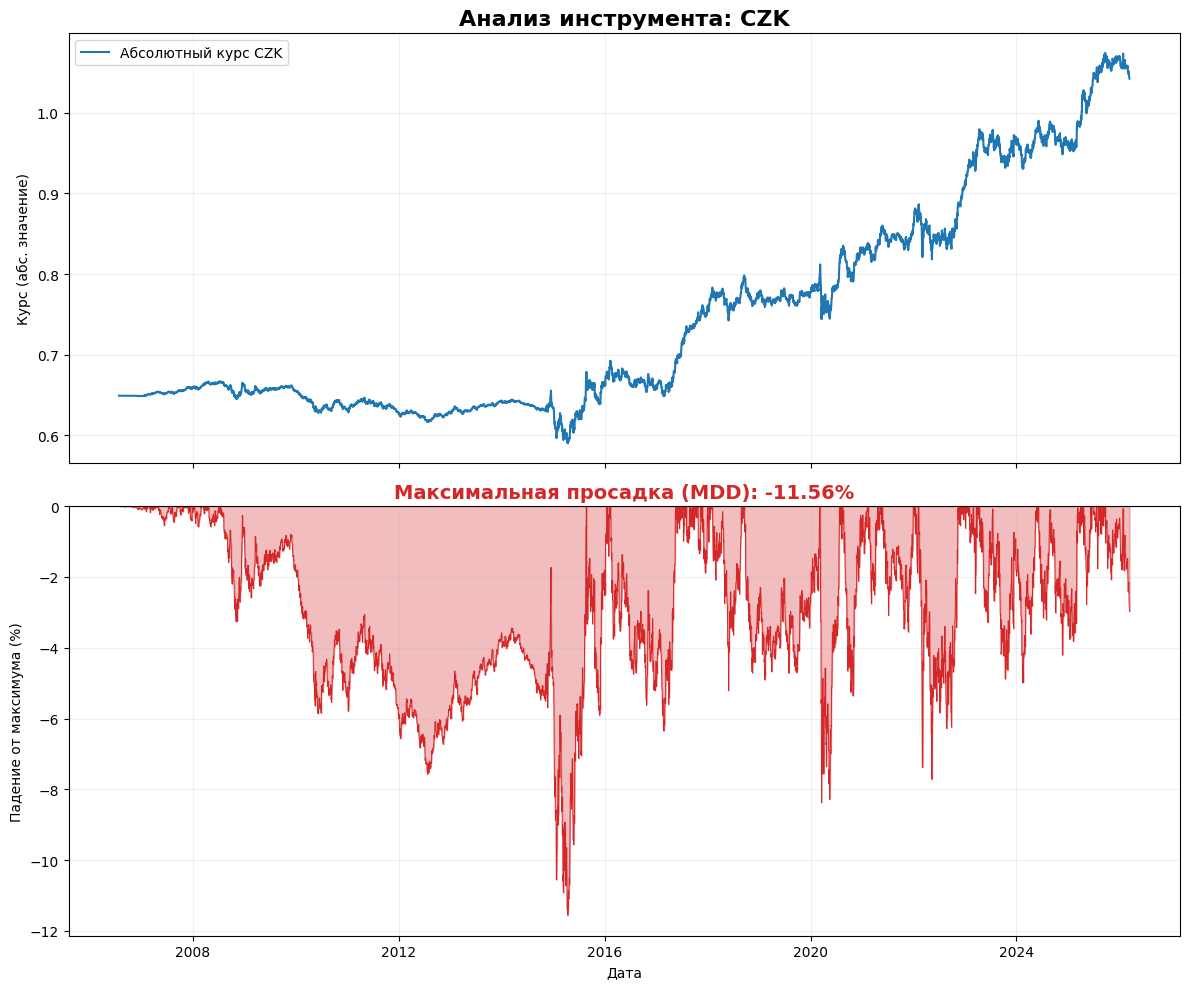

Случайно выбранный актив: CZK
Зафиксированный исторический MDD: -11.56%


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import random

def calculate_mdd(series):
    """
    Функция для расчета максимальной просадки.
    Возвращает текущую просадку (drawdowns) и само значение MDD.
    """
    rolling_max = series.cummax()
    # Умножаем на 100, чтобы сразу получить проценты
    drawdowns = (series - rolling_max) / rolling_max * 100
    mdd = drawdowns.min()
    return drawdowns, mdd

# Убедимся, что дата в индексе (если еще не сделали)
if 'Date' in df.columns:
    df.set_index('Date', inplace=True)

# Выбираем случайный тикер из колонок датафрейма
available_tickers = df.columns.tolist()
random_ticker = random.choice(available_tickers)

target_series = df[random_ticker]

# Выполняем расчет
drawdowns, mdd_value = calculate_mdd(target_series)

# Визуализация
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Верхний график: Динамика абсолютного курса
ax1.plot(target_series.index, target_series, label=f'Абсолютный курс {random_ticker}', color='#1f77b4')
ax1.set_title(f'Анализ инструмента: {random_ticker}', fontsize=16, fontweight='bold')
ax1.set_ylabel('Курс (абс. значение)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.2)

# Нижний график: Подводный график просадок (в процентах)
ax2.fill_between(drawdowns.index, drawdowns, 0, color='#d62728', alpha=0.3, label='Просадка (Drawdown, %)')
ax2.plot(drawdowns.index, drawdowns, color='#d62728', linewidth=0.7)
ax2.set_ylabel('Падение от максимума (%)')
ax2.set_ylim(None, 0) # Ограничиваем сверху нулем для наглядности
ax2.set_title(f'Максимальная просадка (MDD): {mdd_value:.2f}%', color='#d62728', fontsize=14, weight='bold')
ax2.grid(True, alpha=0.2)

# Добавляем подпись оси X только для нижнего графика
plt.xlabel('Дата')

plt.tight_layout()
plt.show()

print(f"Случайно выбранный актив: {random_ticker}")
print(f"Зафиксированный исторический MDD: {mdd_value:.2f}%")

# 📊 Часть 3: Сводный рейтинг исторической просадки (Drawdown Matrix)
В этой таблице представлены расчеты максимальной просадки для каждой валюты за разные временные периоды. 
Это позволяет сравнить устойчивость валют: некоторые могут быть стабильны на коротких отрезках, но иметь катастрофические падения на горизонте 10 лет.

In [3]:
import pandas as pd
import numpy as np
from pandas.tseries.offsets import DateOffset

# 1. Функция честного расчета MDD
def get_mdd_by_date(series, start_date):
    subset = series[series.index >= start_date]
    if subset.empty: return np.nan
    rolling_max = subset.cummax()
    return ((subset - rolling_max) / rolling_max * 100).min()

# 2. Подготовка дат (от последней точки в данных)
last_date = df.index.max()
date_periods = {
    '1 мес': last_date - DateOffset(months=1),
    '3 мес': last_date - DateOffset(months=3),
    '6 мес': last_date - DateOffset(months=6),
    '1 год': last_date - DateOffset(years=1),
    '3 года': last_date - DateOffset(years=3),
    '5 лет': last_date - DateOffset(years=5),
    '10 лет': last_date - DateOffset(years=10)
}

# 3. Сбор данных
mdd_results = []
for ticker in df.columns:
    row = {'Валюта': ticker}
    for p_name, start_dt in date_periods.items():
        row[p_name] = get_mdd_by_date(df[ticker], start_dt)
    mdd_results.append(row)

mdd_table = pd.DataFrame(mdd_results).set_index('Валюта')

# 4. Логика скрытой сортировки по сумме рангов
# Рассчитываем ранги для каждого периода (меньшее значение MDD = 1-е место)
rank_table = mdd_table.rank(method='min', ascending=True)
# Добавляем временную колонку для сортировки
mdd_table['_rank_sum'] = rank_table.sum(axis=1)
# Сортируем и удаляем временную колонку
mdd_table = mdd_table.sort_values(by='_rank_sum', ascending=True).drop(columns=['_rank_sum'])

# 5. Функция для создания гиперссылок
def make_clickable(ticker):
    url = f"https://www.abscur.ru/p/2.html?abs={ticker}"
    return f'<a href="{url}" target="_self">{ticker}</a>'

# 6. Стилизация и вывод
styled_table = mdd_table.style.background_gradient(
    cmap='Reds_r', 
    axis=0
).format("{:.2f}%") \
 .format_index(make_clickable) \
 .set_caption(f"Рейтинг максимальной просадки (MDD) на {last_date.date()}. Сортировка по совокупному риску.")

styled_table

,1 мес,3 мес,6 мес,1 год,3 года,5 лет,10 лет
Валюта,,,,,,,
EGP,-10.13%,-11.03%,-11.72%,-11.72%,-41.56%,-66.41%,-79.91%
ARS,-2.90%,-3.07%,-10.61%,-30.28%,-85.65%,-92.51%,-98.73%
TRY,-0.58%,-4.69%,-7.82%,-20.47%,-55.47%,-80.21%,-91.38%
UAH,-1.56%,-5.62%,-7.59%,-10.95%,-16.83%,-30.07%,-34.77%
CLP,-4.51%,-5.11%,-5.11%,-7.92%,-16.28%,-24.40%,-27.91%
RUB,-2.04%,-3.89%,-5.87%,-9.56%,-26.36%,-39.38%,-39.38%
JPY,-2.30%,-3.33%,-8.22%,-12.96%,-13.46%,-13.46%,-13.46%
COP,-2.58%,-4.80%,-4.80%,-6.63%,-13.44%,-19.88%,-30.02%
KZT,-3.04%,-3.04%,-3.48%,-11.42%,-21.01%,-21.01%,-30.60%
